# AMAZON DATA ANALYSIS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_excel(r"C:\Users\Pc\Downloads\Python case study.xlsx")

## Data Cleaning

In [3]:
df.isnull().sum()

Order ID        0
Order Date      1
Ship Date       0
EmailID         1
Geography       0
Category        0
Product Name    1
Sales           0
Quantity        0
Profit          0
dtype: int64

In [4]:
df.dropna(subset=['Order Date','EmailID','Product Name'],inplace=True)

In [5]:
df[['Country','City','State']]= df['Geography'].str.split(",",expand=True)

## Exploratory Data Analysis

### 1. What are the total Sales, Quantity, and Profit?

In [6]:
print("================================")
print("The total Sales are",df['Sales'].sum().round(2))
print("The total Quantity is",df['Quantity'].sum().round(2))
print("The total Profit are",df['Profit'].sum().round(2))
print("==================================")

The total Sales are 725337.6
The total Quantity is 12255
The total Profit are 108374.76


#### 2. Which are the Top 10 highest selling products?

In [7]:
q1 = df.groupby('Product Name').agg(Highest_selling_products=('Quantity','sum')).sort_values(
    by='Highest_selling_products',ascending=False).head(10)
q1

,Highest_selling_products
Product Name,
Staples,216
"Wilson Jones Clip & Carry Folder Binder Tool for Ring Binders, Clear",32
Cardinal EasyOpen D-Ring Binders,31
Eldon Shelf Savers Cubes and Bins,29
Vinyl Sectional Post Binders,29
LogitechÂ P710e Mobile Speakerphone,29
Memorex Micro Travel Drive 16 GB,28
Dana Halogen Swing-Arm Architect Lamp,28
4009 Highlighters by Sanford,27


### 3. Which category generates the highest Profit?

In [8]:
q2 = df.groupby('Category').agg(Highest_Category_Profit=('Profit','sum')).sort_values(
    by='Highest_Category_Profit',ascending=False)
q2

,Highest_Category_Profit
Category,
Copiers,19327.2351
Accessories,16449.4423
Binders,16096.8016
Paper,12119.2364
Phones,9110.7426
Storage,8643.8550
Appliances,8261.2699
Furnishings,7634.2024
Chairs,4027.5843


### 4. State-wise Sales and Profit Analysis

In [9]:
q4 = df.groupby('State').agg(Total_Sales=('Sales','sum'),Total_Profit=('Profit','sum')).reset_index().round(2)
q4

,State,Total_Sales,Total_Profit
0,Arizona,35241.67,-3436.46
1,California,457607.73,76346.23
2,Colorado,32108.12,-6527.86
3,Idaho,4382.49,826.72
4,Montana,5589.35,1833.33
5,Nevada,16729.10,3316.77
6,New Mexico,4783.52,1157.12
7,Oregon,17431.15,-1190.47
8,Utah,11220.06,2546.53
9,Washington,138641.27,33402.65


### 4. State-wise Sales and Profit Analysis

<Figure size 800x400 with 0 Axes>

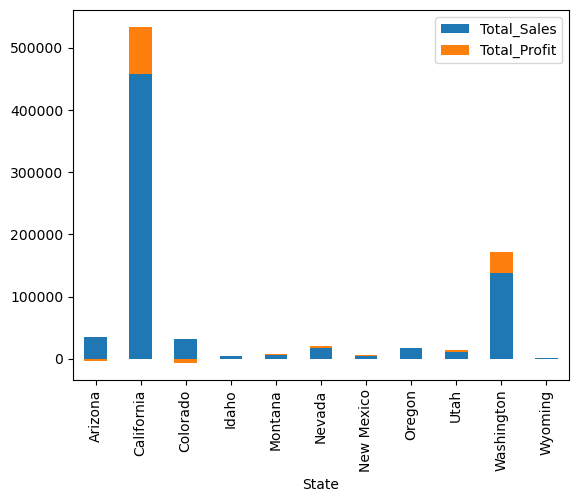

In [11]:
plt.figure(figsize=(8,4))
q4.plot(x='State', y=['Total_Sales','Total_Profit'],kind='bar',stacked=True)
plt.show()

### 5. Monthly Sales Trend

In [12]:
df['Month'] = (df['Order Date'].dt.month.round(2)).astype(str)+"-"+df['Order Date'].dt.month_name()

In [13]:
q5 = df.groupby('Month').agg(Total_Sales=('Sales','sum')).round(2).reset_index()
q5

,Month,Total_Sales
0,1-January,24918.62
1,10-October,57436.80
2,11-November,92988.92
3,12-December,115934.54
4,2-February,16268.62
5,3-March,73023.74
6,4-April,41943.02
7,5-May,45320.87
8,6-June,48519.55
9,7-July,64690.13


### 6. Year-wise performance of Sales and Profit

In [14]:
df['Year']=df['Order Date'].dt.year

In [15]:
q6 = df.groupby('Year').agg(Total_Sales=('Sales','sum'),Total_Profit=('Profit','sum')).reset_index().round(2)
q6

,Year,Total_Sales,Total_Profit
0,2019,147883.03,20065.69
1,2020,139886.35,20457.04
2,2021,186935.69,23951.40
3,2022,250632.53,43900.63


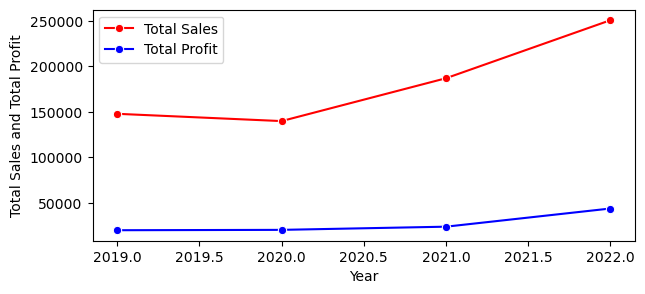

In [16]:
plt.figure(figsize=(7,3))
sns.lineplot(data = q6, x = 'Year', y = 'Total_Sales',color = 'red',marker = 'o',label='Total Sales')
sns.lineplot(data = q6, x = 'Year', y = 'Total_Profit',color = 'blue',marker = 'o',label='Total Profit')
plt.legend()
plt.ylabel('Total Sales and Total Profit')
plt.show()


### 7. Which customers placed the highest number of orders?

In [41]:
q7= df.groupby('EmailID')['Order ID'].nunique().sort_values(ascending=False).head(10)
q7

EmailID
BillDonatelli@gmail.com      7
ArianneIrving@gmail.com      7
SallyHughsby@gmail.com       7
SanjitEngle@gmail.com        7
LoganHaushalter@gmail.com    6
HenryGoldwyn@gmail.com       6
RickWilson@gmail.com         6
ArthurPrichep@gmail.com      6
JeremyFarry@gmail.com        6
RubenDartt@gmail.com         6
Name: Order ID, dtype: int64

### 8. Which products have negative profit (loss-making)?

In [17]:
q8 = df.groupby('Product Name').agg(Total_Profit=('Profit','sum')).round(2).reset_index()
q8

,Product Name,Total_Profit
0,"""While you Were Out"" Message Book, One Form pe...",3.71
1,#10 Self-Seal White Envelopes,10.87
2,"#10 White Business Envelopes,4 1/8 x 9 1/2",41.06
3,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",28.75
4,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",44.92
...,...,...
1489,iKross Bluetooth Portable Keyboard + Cell Phon...,10.06
1490,iOttie HLCRIO102 Car Mount,-6.00
1491,iOttie XL Car Mount,-17.99
1492,invisibleSHIELD by ZAGG Smudge-Free Screen Pro...,55.41


### 9. What is the Average Order Value (AOV)?

In [18]:
q9 = df.groupby('Order ID').agg(Total_Sales=('Sales','sum')).round(2).reset_index()
print("The average order value is", q9['Total_Sales'].mean().round())

The average order value is 451.0


### 10. How many repeat customers do we have?

In [19]:
q10 = df.groupby('EmailID').agg(Total_Orders=('Order ID','count')).reset_index()
q10[q10['Total_Orders']>1]

,EmailID,Total_Orders
0,AaronBergman@gmail.com,3
1,AaronHawkins@gmail.com,5
2,AaronSmayling@gmail.com,3
3,AdamBellavance@gmail.com,5
4,AdamHart@gmail.com,5
...,...,...
681,XylonaPreis@gmail.com,12
682,YanaSorensen@gmail.com,7
683,YosephCarroll@gmail.com,2
684,ZuschussCarroll@gmail.com,16


### 11. Which category sells the most quantity?

In [23]:
q11 = df.groupby('Category').agg(Most_quantity=('Sales','sum')).round(2).reset_index()
q11

,Category,Most_quantity
0,Accessories,61034.22
1,Appliances,30236.34
2,Art,9212.07
3,Binders,55961.11
4,Bookcases,36004.12
5,Chairs,101781.33
6,Copiers,49749.24
7,Envelopes,4118.10
8,Fasteners,923.22
9,Furnishings,30049.17


### 12. Calculate Profit Margin % for each product

In [26]:
q12 = df.groupby('Product Name').agg(Total_Sales=('Sales','sum'),Total_profit=('Profit','sum')).round(2)
q12['Profit Margin(In Percentage)'] = (q12['Total_profit'] / q12['Total_Sales'])*100


,Total_Sales,Total_profit,Profit Margin(In Percentage)
Product Name,,,
"""While you Were Out"" Message Book, One Form per Page",7.42,3.71,50.000000
#10 Self-Seal White Envelopes,22.18,10.87,49.008115
"#10 White Business Envelopes,4 1/8 x 9 1/2",90.89,41.06,45.175487
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",61.18,28.75,46.992481
"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",91.68,44.92,48.996510
...,...,...,...
"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",100.56,10.06,10.003978
iOttie HLCRIO102 Car Mount,31.98,-6.00,-18.761726
iOttie XL Car Mount,79.96,-17.99,-22.498749


### 13. Which is the most profitable month?

In [29]:
q13 = df.groupby('Month').agg(Total_Profit=('Profit','sum')).sort_values(
    by='Total_Profit',ascending=False).reset_index()
q13

,Month,Total_Profit
0,3-March,16094.8756
1,9-September,14694.8599
2,12-December,13258.6218
3,11-November,13095.0634
4,8-August,11077.6051
5,7-July,9281.3346
6,6-June,7730.0003
7,10-October,7655.0179
8,5-May,6800.4482
9,1-January,4565.5290


### 14. What is the average shipping time?

In [31]:
df['Ship Time'] = (df["Ship Date"] - df['Order Date']).dt.days

In [33]:
print("The average shipping time is",df['Ship Time'].mean().round(2))

The average shipping time is 3.93


### 15. Does Shipping Time impact Profit? (Correlation)

<Axes: xlabel='Ship Time', ylabel='Profit'>

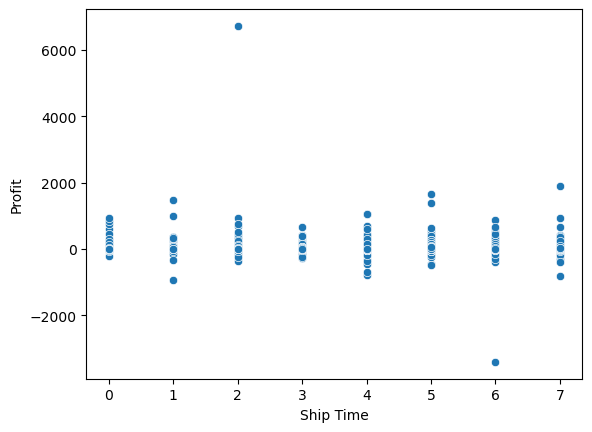

In [35]:
sns.scatterplot(data = df, x ='Ship Time',y = 'Profit')

In [36]:
df[['Profit','Ship Time']].corr()

,Profit,Ship Time
Profit,1.000000,-0.028511
Ship Time,-0.028511,1.000000


In [37]:
print("The Shipping time does affect the profit as per the correlation matrix result is -0.028")

The Shipping time does affect the profit as per the correlation matrix result is -0.028


In [38]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'EmailID', 'Geography',
       'Category', 'Product Name', 'Sales', 'Quantity', 'Profit', 'Country',
       'City', 'State', 'Month', 'Year', 'Ship Time'],
      dtype='object')

In [39]:
df

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit,Country,City,State,Month,Year,Ship Time
0,CA-2021-138688,2021-06-13,2021-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,United States,Los Angeles,California,6-June,2021,4
1,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,United States,Los Angeles,California,6-June,2019,5
2,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656,United States,Los Angeles,California,6-June,2019,5
3,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,United States,Los Angeles,California,6-June,2019,5
4,CA-2019-115812,2019-06-09,2019-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,United States,Los Angeles,California,6-June,2019,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3198,CA-2021-125794,2021-09-30,2021-10-04,MarisLaWare@gmail.com,"United States,Los Angeles,California",Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.240,1,15.2208,United States,Los Angeles,California,9-September,2021,4
3199,CA-2022-121258,2022-02-27,2022-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,15.6332,United States,Costa Mesa,California,2-February,2022,5
3200,CA-2022-121258,2022-02-27,2022-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Phones,Aastra 57i VoIP phone,258.576,2,19.3932,United States,Costa Mesa,California,2-February,2022,5
3201,CA-2022-121258,2022-02-27,2022-03-04,DaveBrooks@gmail.com,"United States,Costa Mesa,California",Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,13.3200,United States,Costa Mesa,California,2-February,2022,5
